# Part A - Dataset Exploration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import os
import kagglehub

# Remove the api key
## Data loading -

In [ ]:
kagglehub.login()


In [ ]:
path = kagglehub.competition_download('shopee-product-matching')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/shopee-product-matching


In [ ]:
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
train_df.head()

,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   posting_id   34250 non-null  object
 1   image        34250 non-null  object
 2   image_phash  34250 non-null  object
 3   title        34250 non-null  object
 4   label_group  34250 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.3+ MB


In [ ]:
train_df.shape

(34250, 5)

### Analysis of Columns and their functions:
- `posting_id` is like an id attached to each product
- `image` column contains the filename of each image of the product
- `image_pash` is a encoding where the entire image is compressed down. It can be used for figuring out exactly identical images or visually similar images.
- `title` gives us the product title which inturn gives us the product description.
- `label_group` has the labels that are assigned to same products.

# EDA

In [ ]:
label_counts.min(),label_counts.max()

(2, 51)

In [ ]:
print("listings:", len(train_df))
print("product groups:", train_df.label_group.nunique())
print("unique image files:", train_df.image.nunique())
print("unique phashes:", train_df.image_phash.nunique())
print("unique titles:", train_df.title.nunique())
print("share of groups with exactly 2 listings:", round((label_counts == 2).mean(), 3))
n = len(train_df)
print("all possible pairs:", f"{n*(n-1)//2}")

listings: 34250
product groups: 11014
unique image files: 32412
unique phashes: 28735
unique titles: 33117
share of groups with exactly 2 listings: 0.634
all possible pairs: 586514125


## Label Analysis

In [ ]:
label_counts = train_df['label_group'].value_counts()
print(label_counts.head(5))
label_counts.describe()


label_group
562358068     51
159351600     51
3113678103    51
3627744656    51
994676122     51
Name: count, dtype: int64


,count
count,11014.000000
mean,3.109679
std,2.940827
min,2.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,51.000000


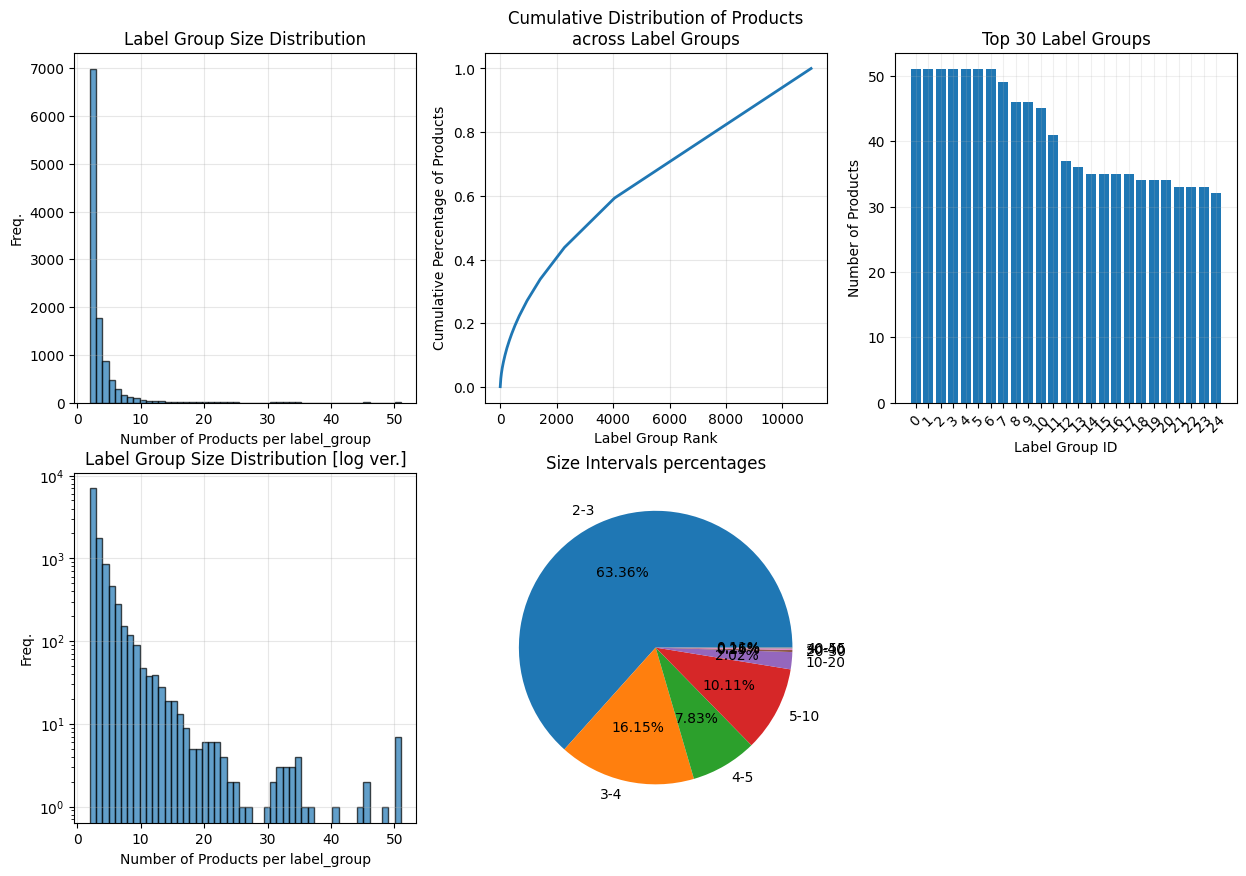

In [ ]:
plt.figure(figsize=(15, 10))

# Label Group Size Distribution
plt.subplot(2,3,1)
plt.hist(label_counts,bins=50,alpha=0.7,log=False,edgecolor="black")
plt.xlabel('Number of Products per label_group')
plt.ylabel('Freq.')
plt.title('Label Group Size Distribution')
plt.grid(alpha=0.3)

#Cumulative Distribution
plt.subplot(2, 3, 2)
cumulative = np.cumsum(label_counts.values) / np.sum(label_counts.values)
plt.plot(range(1, len(cumulative) + 1), cumulative, linewidth=2)
plt.xlabel('Label Group Rank')
plt.ylabel('Cumulative Percentage of Products')
plt.title('Cumulative Distribution of Products\nacross Label Groups')
plt.grid(True, alpha=0.3)

# Top 25 labels
plt.subplot(2,3,3)
top_labels = label_counts.head(25)
plt.bar(range(len(top_labels)), top_labels.values)
plt.title("Top 30 Label Groups")
plt.xlabel("Label Group ID")
plt.ylabel("Number of Products")
plt.xticks(range(len(top_labels)),range(len(top_labels)), rotation=45)
plt.grid(alpha=0.2)

# Label Group Size Distribution- Log scale
plt.subplot(2,3,4)
plt.hist(label_counts,bins=50,alpha=0.7,log=True,edgecolor="black")
plt.xlabel('Number of Products per label_group')
plt.ylabel('Freq.')
plt.title('Label Group Size Distribution [log ver.]')
plt.grid(alpha=0.3)

# pie plot of percentages of size intervals
size_bins=[2,3,4,5,10,20,30,40,55]
size_labels=["2-3","3-4","4-5","5-10","10-20","20-30","30-40","40-55"]
size_vals=[]
for i in range(len(size_bins)-1):
    count=label_counts[label_counts>=size_bins[i]]
    count=count[count<size_bins[i+1]]
    size_vals.append(len(count))
plt.subplot(2,3,5)
plt.pie(size_vals,labels=size_labels,autopct='%2.2f%%')
plt.title("Size Intervals percentages")
plt.grid(alpha=0.2)



plt.show()

### Inferences from plots

- Most of the labels contain 2-5 items
- The label group size distribution is exponential in nature.
- Only the top 11 groups contain more than 40 elements
- The cumulative distribution is almost linear indicating that the size of each grp is actually not that big [max=51]. And the initial bulge indicates big groups hold most of the items.

## Image analysis


In [ ]:
def show_images_with_same_label(df,label,max_images=8):
  grp=df[df["label_group"]==label]
  n=min(len(grp),max_images)
  if n==0:
    print("No items present in this label_group")
    return
  plt.figure(figsize=(15,5))
  grp=grp.head(n)
  image_dir=os.path.join(path,"train_images")
  l=[]
  for i in range(n):
    plt.subplot(2,n//2+1,i+1)
    img_path=os.path.join(image_dir,grp.iloc[i]["image"])
    img=Image.open(img_path)
    plt.imshow(img)
    plt.title(grp.iloc[i]["image_phash"])
    plt.axis("off")
    l.append(grp.iloc[i]["title"])
  plt.show()
  print("\nTitles of the products:")
  for i in range(len(l)):
    print(f"{i+1} . {l[i]}")



--------------------
--------------------


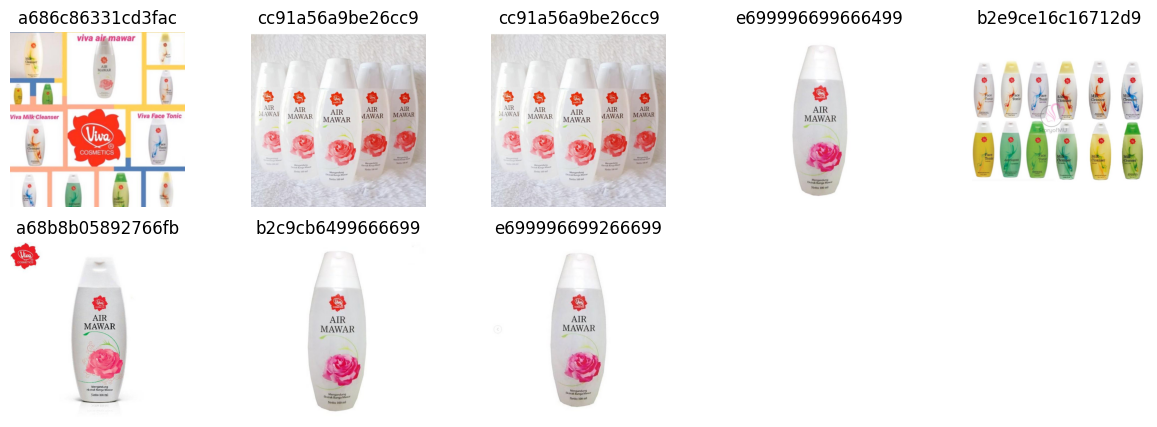


Titles of the products:
1 . VIVA Cleansing Milk, VIVA Air Mawar, VIVA Face Toner 100ml
2 . VIVA AIR MAWAR 100ML
3 . Viva air mawar 100ml
4 . VIVA Air Mawar 100 ml
5 . VIVA Air Mawar / Face Tonic / Milk Cleanser 100ml / 200ml [toner penyegar / susu pembersih]
6 . VIVA Cosmetics Air Mawar 100ml
7 . VIVA Air Mawar 100 ml | Air Mawar Viva Pembersih
8 . Viva Air Mawar Termurah 100% Original
--------------------
--------------------
--------------------
--------------------


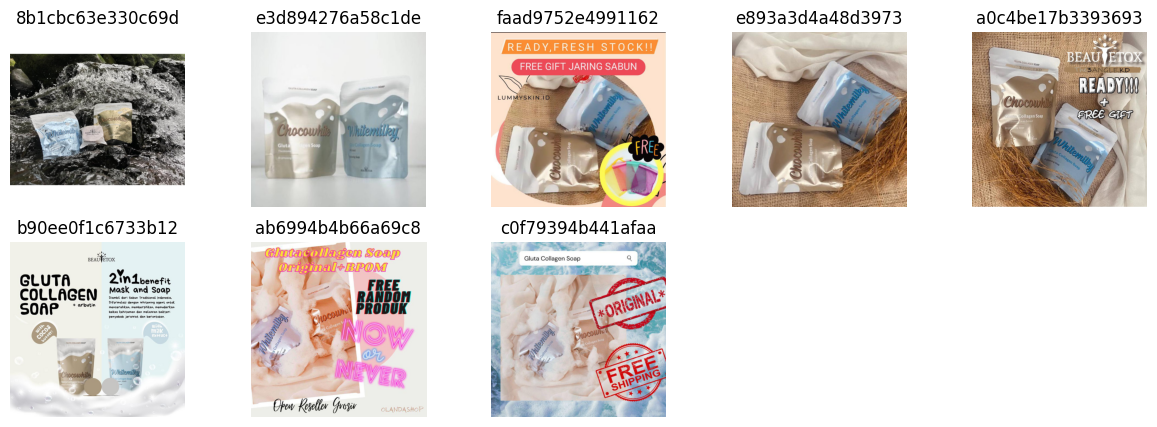


Titles of the products:
1 . Ready Stock - Gluta Collagen Soap By Beautetox / Sabun Viral Tiktok / Sabun gluta colagen
2 . GLUTA COLLAGEN SOAP BY BEAUTETOX SKINSUPERSTAR
3 . KIRIM SETIAP HARI!! GLUTA COLLAGEN SOAP BEAUTETOX CHOCOWHITE WHITEMILKY
4 . [Ready & Resmi] Gluta Soap Beautetox Viral
5 . READY STOK [THE3ANGLE-KD] Gluta Collagen Beautetox Chocowhite Whitemilky NEW PACKAGING - FREE GIFT**
6 . [READY SIAP KIRIM] GLUTA COLLAGEN SOAP
7 . (DISKON 11-11 BURUAN ORDER) Sabun Whitening Gluta Collagen Beautetox Chocowhite Whitemilky ORIGINAL
8 . [FREE JARING SABUN] Gluta Collagen Soap [READY]
--------------------
--------------------
--------------------
--------------------


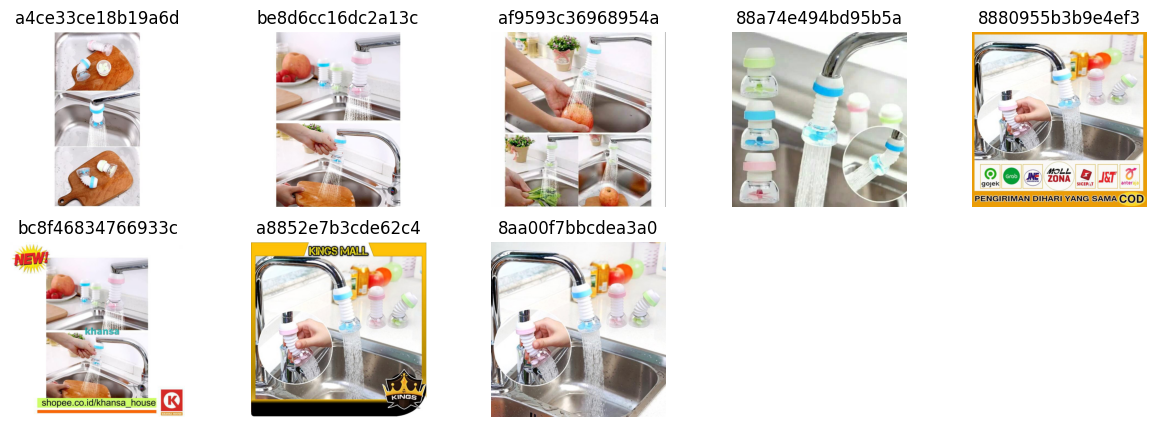


Titles of the products:
1 . 832P - FLEXIBLE Sambungan Kran FLEXIBLE irit air Keran Splash shower--168--
2 . DMR Sambungan Kran FLEXIBLE irit air Keran Splash Shower 0515
3 . [ACQ] Saringan Kran Air Flexible \xe2\x80\xa2360 [Kode A1]
4 . Sambungan Kran Air fleksibel Filter air Anti Splash Shower wastafel kamar mandi toilet dapur
5 . SAMBUNGAN KRAN AIR FLEXSIBLE PENYARING KERAN AIR FAUCET FILTER K40
6 . Hub Keran Sambungan Keran Keranair Keran Cuci Piring Keran Angsa /Flexible /Kh106
7 . Kings- H722 Sambungan Saringan Penghemat Air Fleksibel / Berputar 360 Derajat / Water Filter
8 . GBI Sambungan Kran Air / Keran Hemat Air Berputar 360drajat Aerator Irit Air
--------------------
--------------------
--------------------
--------------------


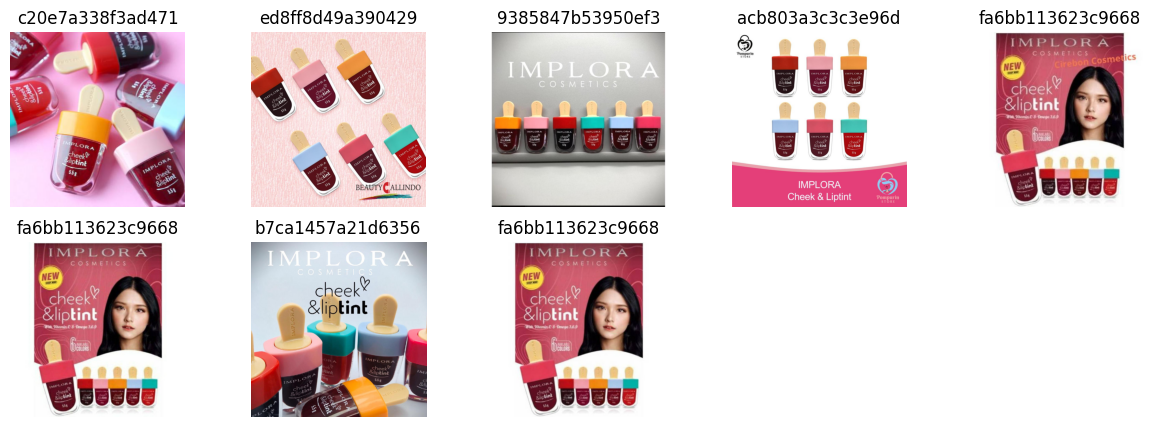


Titles of the products:
1 . IMPLORA CHEEK & LIPTINT - IMPLORA LIP TINT ORIGINAL BPOM
2 . IMPLORA CHEEK & LIPTINT
3 . Lip Tint Implora Cheek & Liptint
4 . IMPLORA Cheek & Lip Tint Model Ice Cream - Set Liptint & Pemerah Pipi
5 . {Promo murah} Implora cheek&liptint
6 . Implora Cheek and Liptint/ Lip Tint implora
7 . IMPLORA CHEEK LIP TINT
8 . New cheek dan Liptint/ lip tint by IMPLORA bpom
--------------------
--------------------
--------------------
--------------------


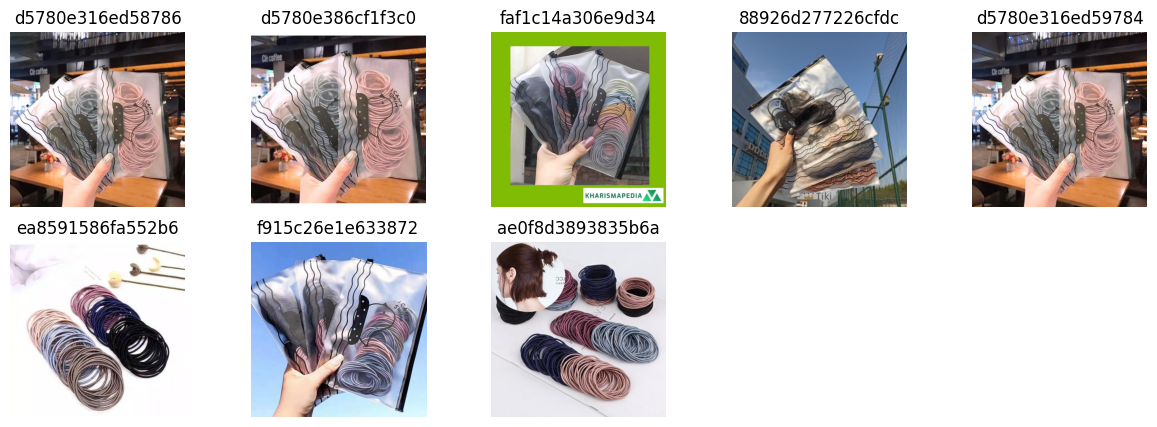


Titles of the products:
1 . KARET KUCIR PREMIUM
2 . 100Pcs Karet Ikat Rambut Elastis untuk Wanita
3 . 100 Pcs Ikat Rambut Karet Polos Elastis Gaya Korea untuk Wanita
4 . 100/1000 Pcs Ikat Rambut Korea Karet Polos Elastis Gaya Korea Untuk Wanita
5 . Korea women children hair tie head rope karet gelang elastis
6 . Ikat Rambut Karet Polos Elastis Gaya Korea untuk Wanita
7 . 50Pcs Ikat Rambut Korea Karet rambut Polos Elastis Gaya Korea Untuk Wanita kuncir tail rambut
8 . 1pcs Kunciran Rambut Karet / Kuncir Rambut Karet Warna Warni RANDOM COLOUR
--------------------
--------------------


In [ ]:
labels_shown=5
for i in range(labels_shown):
  print("-"*20)
  print("-"*20)
  show_images_with_same_label(train_df,label_counts.index[i])
  print("-"*20)
  print("-"*20)


### Inferences:
- The products with same labels have the product images same in many cases.
- The product titles have similar and often common words between them.
- Many words in the titles are often common in all of them.
- In general, same label products have either the same image as the product image or very similar images in terms of several iterations or different camera angles, etc.
- Many of them have the sam image_phash as well.

## Small-Groups Analysis

In [ ]:
group_2=label_counts[label_counts==2]
group_3=label_counts[label_counts==3]
group_4=label_counts[label_counts==4]
group_5to10=label_counts[(label_counts>=5) & (label_counts<=10)]

--------------------


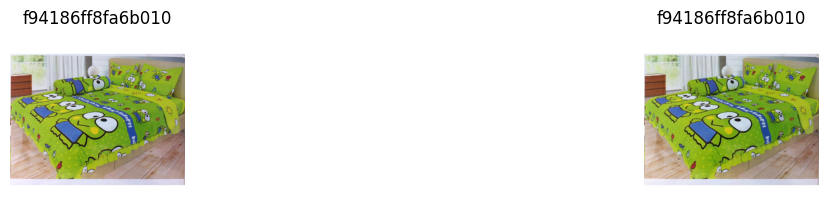


Titles of the products:
1 . Sprei Lady Rose 180x200 King terlaris Keroppi
2 . Sprei king ladyrose size 180x200 kerokeroppi
--------------------
--------------------


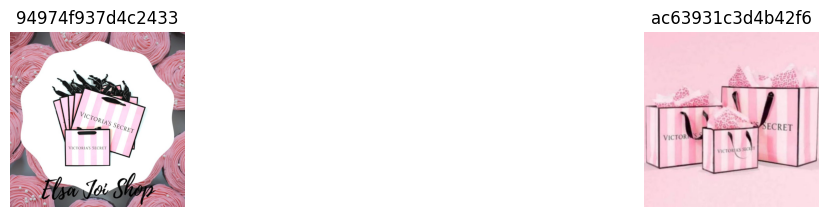


Titles of the products:
1 . Paper Bag Victoria Secret
2 . PAPER BAG VICTORIA SECRET
--------------------
--------------------


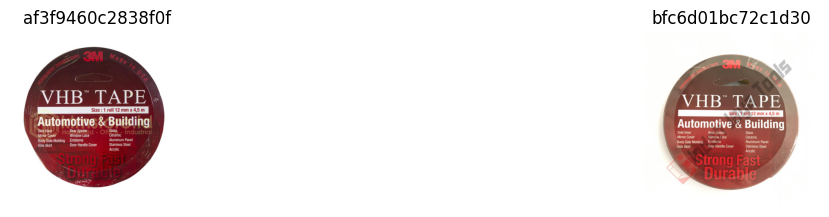


Titles of the products:
1 . Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DOUBLE FOAM TAPE
2 . Double Tape VHB 3M ORIGINAL 12mm x 4.5mm Busa Perekat
--------------------
--------------------


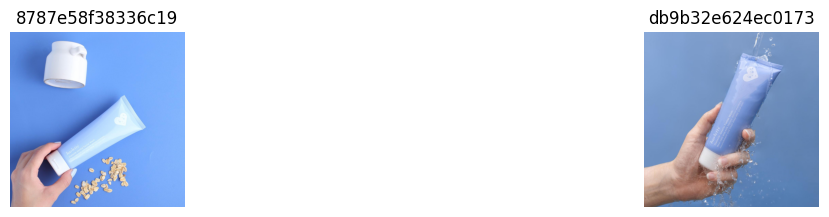


Titles of the products:
1 . GENTLE FACIAL WASH OATMILK HARLETTE
2 . Harlette Oatmilk Gentle Facial Wash
--------------------
--------------------


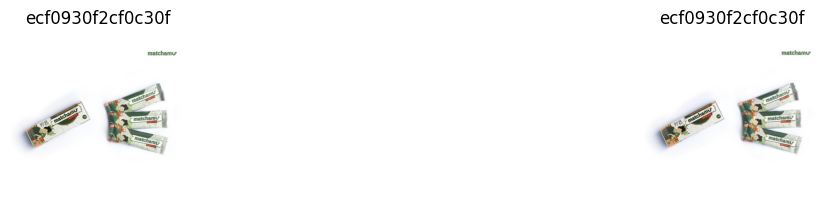


Titles of the products:
1 . Matchamu Matcha Latte Box of 3
2 . Matcha Latte Enak Matchamu
--------------------


In [ ]:
# 2-Item groups
any_5=group_2.head(5)
for i in range(5):
  print("-"*20)
  show_images_with_same_label(train_df,group_2.index[i])
  print("-"*20)

--------------------


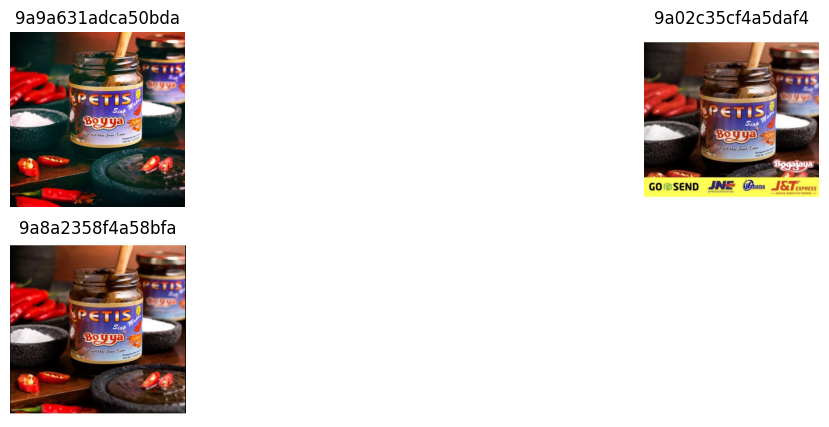


Titles of the products:
1 . Sambal Petis Bumbu Udang Pedas Boyya 270 gram Petis Siap Saji Bogajaya
2 . Petis Boyya Surabaya
3 . BEST SELLER! SAMBAL PETIS BOYYA KHAS SURABAYA 270 GRAM
--------------------
--------------------


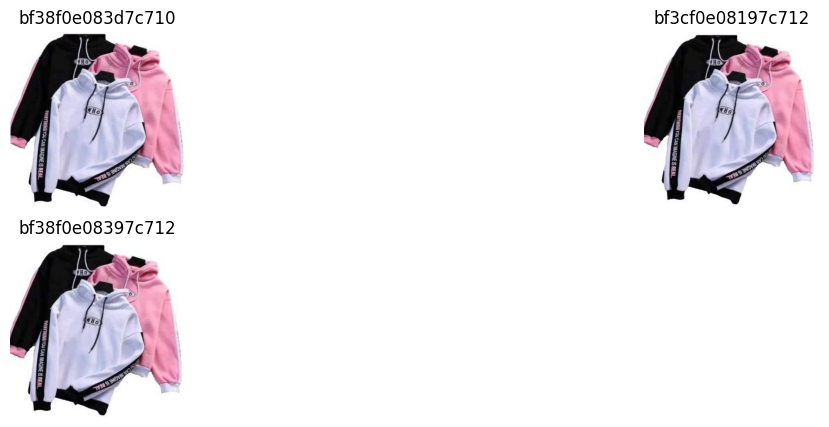


Titles of the products:
1 . HnKfashion Sweater Hoodie WHO Printing BabyTerry - Fit L
2 . CT2fashion Sweater Hoodie Wanita WHO Printing
3 . MichelleStore Sweater Hoodie Wanita WHO Printing
--------------------
--------------------


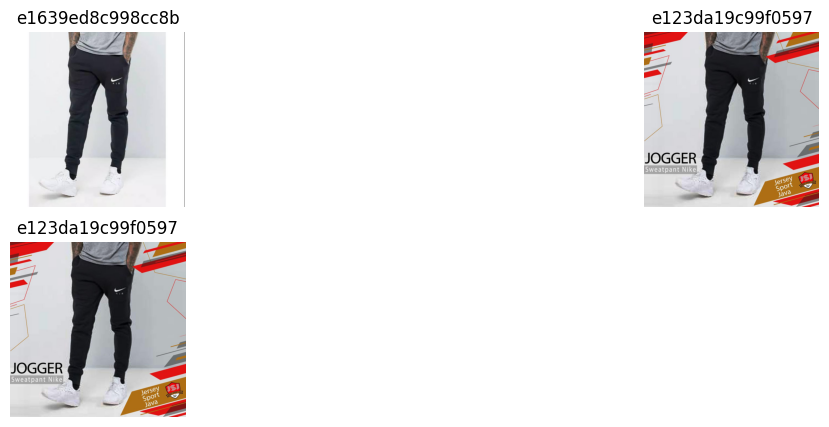


Titles of the products:
1 . CELANA JOGGER PANJANG / SWEATPANTS / TRENING NIKE AIR
2 . BEST SELLER - CELANA JOGGER PANJANG SWEATPANTS/TRENING OLAHRAGA NIKE AIR
3 . BEST SELLER - CELANA JOGGER PANJANG/SWEATPANTS TRENING NIKE AIR NEW - GRADE ORI
--------------------
--------------------


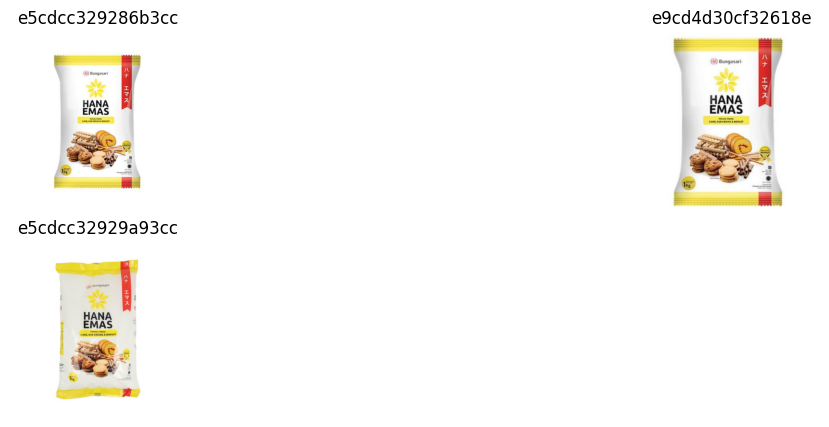


Titles of the products:
1 . Hana Emas Tepung Terigu 1 kg
2 . Hana Emas 1 Kg [ Terigu Protein Rendah ]
3 . Tepung Terigu Hana Emas 1 Kg
--------------------
--------------------


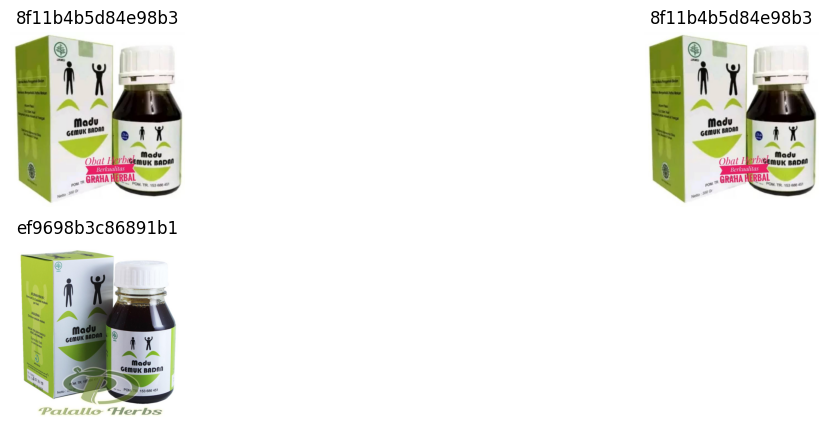


Titles of the products:
1 . Madu Gemuk Badan 350gr - Penambah Berat Badan. Nafsu Makan. Lahap Habis. Semok dan Sehat dgn Herbal
2 . Madu Gemuk Badan 350gr - Rangsang Nafsu Makan. Lahap. Nikmat dan Sehat
3 . Madu Penggemuk Badan Dewasa| Gemuk Badan Menggemukan Badan Dengan Aman Tanpa Efek Samping
--------------------


In [ ]:
# 3-Item groups
any_5=group_3.head(5)
for i in range(5):
  print("-"*20)
  show_images_with_same_label(train_df,group_3.index[i+5])
  print("-"*20)

--------------------


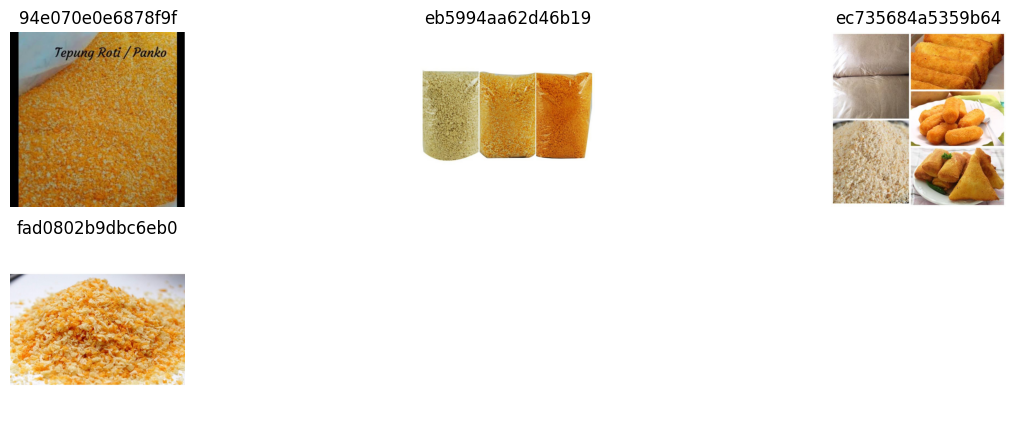


Titles of the products:
1 . Tepung roti/tepung panir panko repack 500gr
2 . Tepung Panko/Tepung Roti/Panir 500 gr
3 . Tepung roti / panir halus 500gr
4 . TEPUNG ROTI / PANIR / BREAD CRUMB 500gr
--------------------
--------------------


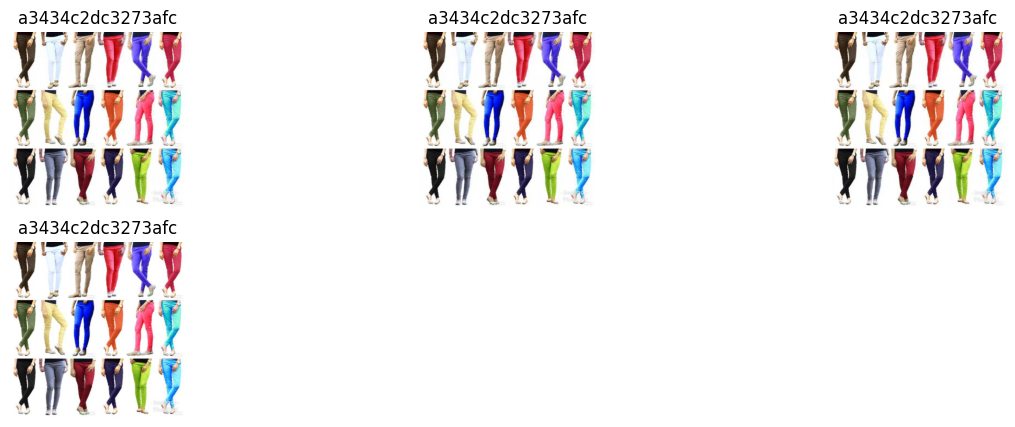


Titles of the products:
1 . CELANA BAHAN WANITA PANJANG 96cm MODEL PENSIL XL NO.31-32-33-33.5
2 . CELANA BAHAN WANITA PANJANG 96cm MODEL PENSIL XXL NO.34-35-36
3 . CELANA BAHAN WANITA PANJANG 96cm MODEL PENSIL XXXL NO.37-38-39
4 . Celana katun polos anti begah wanita cotton pants cewek diskon grosir original Beels
--------------------
--------------------


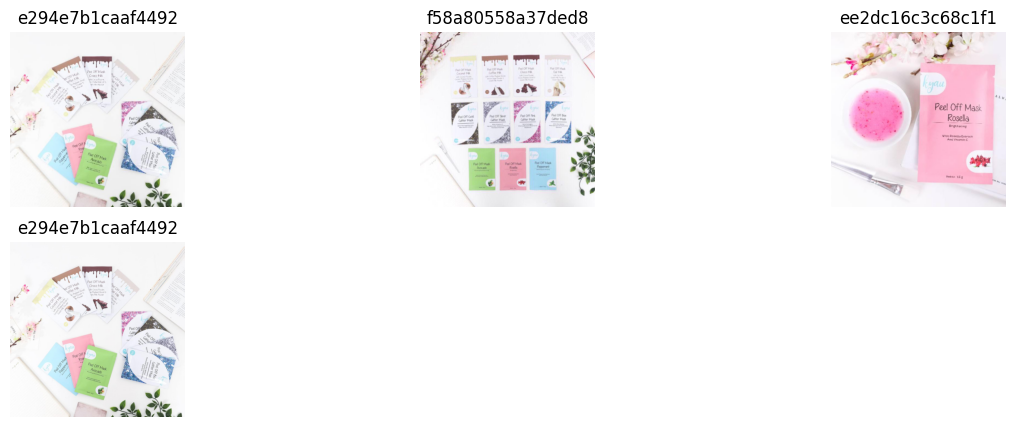


Titles of the products:
1 . [DIST RESMI] KYAU peel off mask 15gr
2 . [BPOM] KYAU PEEL OFF MASK WITH PETAL GLITTER HYDRATING  15gr
3 . KYAU Peel Off Mask Rosella 15G
4 . KYAU Peel Off mask 15G
--------------------


In [ ]:
# 4-Item groups
any_3=group_4.head(3)
for i in range(3):
  print("-"*20)
  show_images_with_same_label(train_df,group_4.index[i])
  print("-"*20)

--------------------


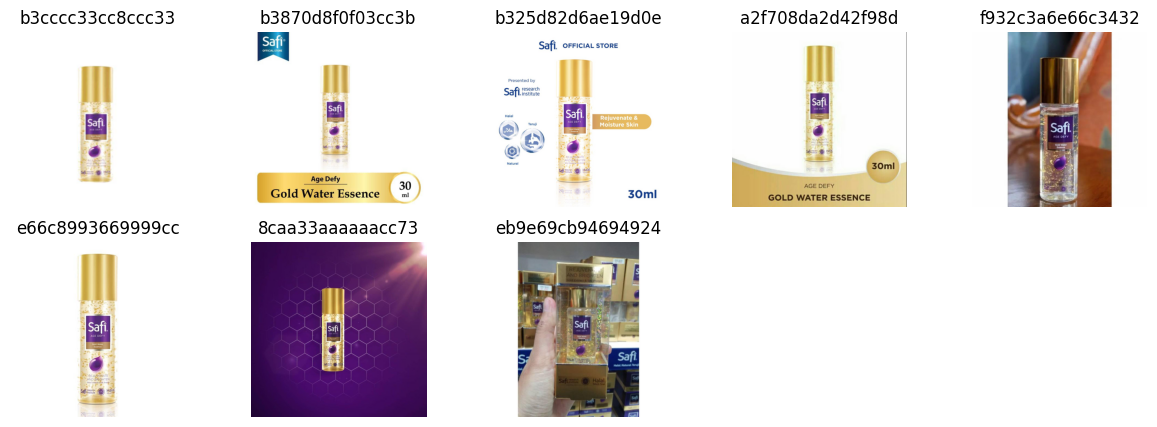


Titles of the products:
1 . Safi  Age Defy Gold Water Essence 30ml
2 . Safi Age Defy Gold Water Essence 30 ml Anti Aging
3 . Safi Age Defy Gold Water Essence 30 ml
4 . Safi Age Defy Gold Water Essence 30 ml.
5 . Safi Age Defy Gold Water Essence 30 ml
6 . SAFI Age Defy Gold Water Essence 30ml
7 . Safi Age Defy Gold Water Essence 30 ml
8 . SAFI AGE DEFY GOLD WATER ESSENCE 30ml
--------------------
--------------------


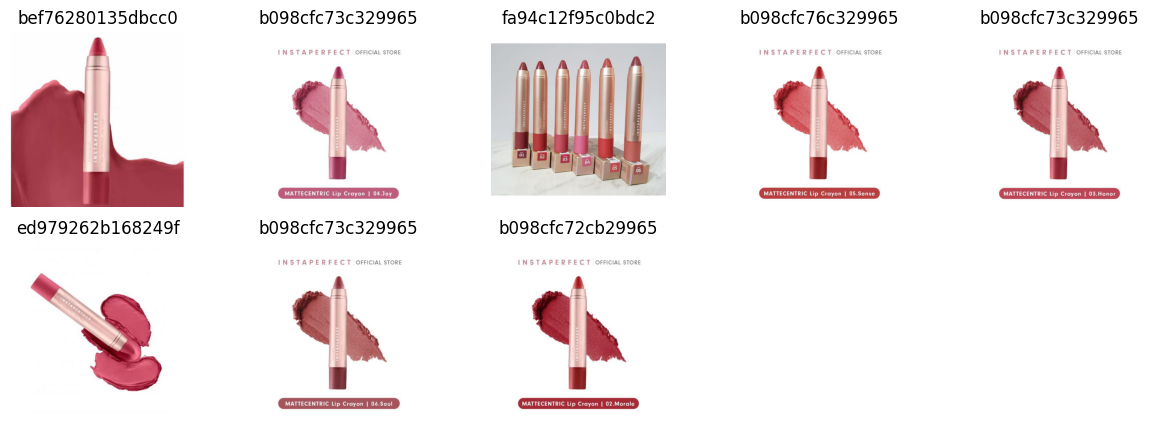


Titles of the products:
1 . WARDAH INSTAPERFECT Mattecentric Lip Crayon
2 . Instaperfect MATTECENTRIC Lip Crayon 04. JOY 3 g
3 . Wardah Instaperfect Mattecentric Lip Crayon 3 Gr
4 . Instaperfect MATTECENTRIC Lip Crayon 05. SENSE 3 g
5 . Instaperfect MATTECENTRIC Lip Crayon 03. HONOR 3 g
6 . Wardah Instaperfect Mattecentric Lip Crayon 3g
7 . Instaperfect MATTECENTRIC Lip Crayon 06. SOUL 3 g
8 . Instaperfect MATTECENTRIC Lip Crayon 02. MORALE 3 g
--------------------
--------------------


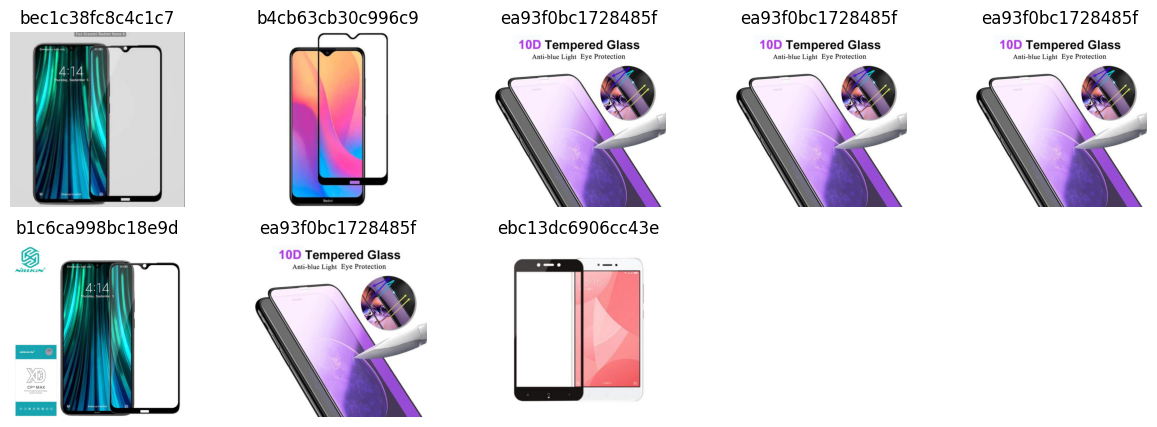


Titles of the products:
1 . Tempered glass Nillkin XD cp+ cpplus Max Xiaomi Redmi Note 8
2 . TEMPERED GLASS 5D/6D/9D FULL COVER XIAOMI REDMI 9/7/7A/8A/8/GO/S2
3 . ANTI BLUELIGHT TEMPERED GLASS 10D FULL COVER ALL TIPE HP
4 . ANTI BLUELIGHT TEMPERED GLASS 10D FULL COVER IPHONE 6G/6S/6+/6S+/7G/8G/7+/8+/X/XS/XR/XS MAX
5 . ANTI BLUELIGHT TEMPERED GLASS 10D FULL COVER XIAOMI REDMI NOTE 7/7/7A/S2/MI PLAY/POCOPHONE F1/NOTE 6
6 . NILLKIN Lapisan Pelindung Full Screen Anti Pecah untuk Xiaomi Redmi Note 8 film
7 . TEMPERED GLASS ANTI BLUELIGHT ANTI RADIASI 10D FULL COVER A31/A51/A71 Dan ALL TYPE
8 . TEMPERED GLASS 5D/6D/9D FULL COVER XIAOMI REDMI 4A/REDMI 5/REDMI 5 PLUS/REDMI 5A/REDMI 5X/MI A1
--------------------
--------------------


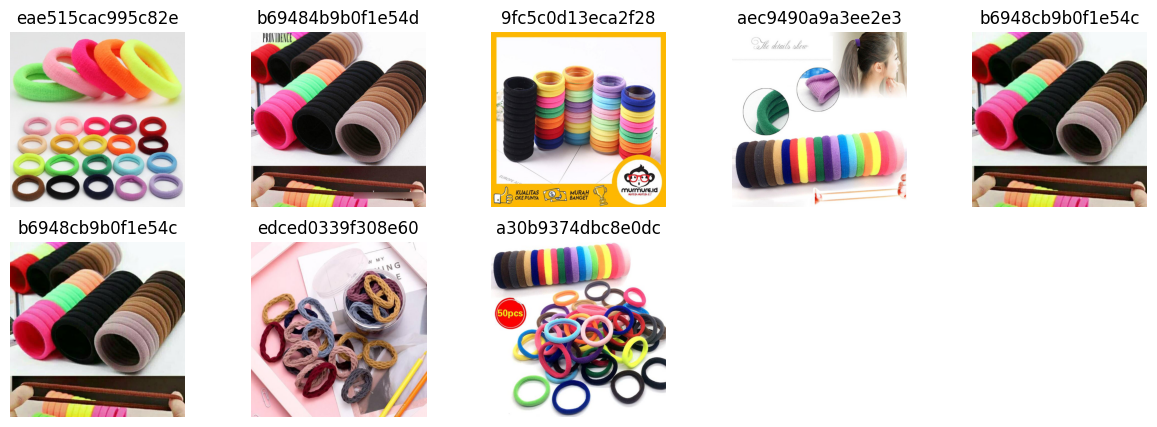


Titles of the products:
1 . KARET IKAT RAMBUT POLOS KOREA / KARET JEPANG SIMPLE ELEGAN / KUNCIR RAMBUT
2 . [Bayar Di Tempat]50Pcs Ikat Rambut Elastis untuk Wanita
3 . MURMURE.ID | KARET IKAT RAMBUT POLOS KOREA / KARET JEPANG SIMPLE ELEGAN / KUNCIR RAMBUT HA012
4 . JOLIECOLLECTIONS KARET IKAT RAMBUT POLOS KOREA / KARET JEPANG SIMPLE ELEGAN / KUNCIR RAMBUT
5 . IKAT RAMBUT KUALITAS BAGUS TIDAK MELAR
6 . [MURAH] IKAT RAMBUT KUALITAS BAGUS TIDAK MELAR
7 . KARET IKAT RAMBUT POLOS KOREA / KARET JEPANG SIMPLE ELEGAN / KUNCIR RAMBUT S0043
8 . 50Pcs Karet Rambut Ponytail Elastis untuk Wanita
--------------------


In [ ]:
# 2-Item groups
any_5=group_5to10.head(4)
for i in range(4):
  print("-"*20)
  show_images_with_same_label(train_df,group_5to10.index[i])
  print("-"*20)

### Inferences
- Even among the small groups, the pattern holds true.
- Most of them have similar images.
- Many of them have the same image.
- Some of the images have the same overall content, but due to the presence of extra features like lighting differences or added texts, their  image_phash is different.
- The titles have a similar trend.
- The titles have many common words between them and some of them are exactly same.

## Exact same title and image_phash analysis

In [ ]:
def find_same_title_image_phash(df,label,max_examples=5):
  print("label: ",label)
  label_grp=df[df["label_group"]==label]
  duplicate_image_phash=label_grp[label_grp["image_phash"].duplicated(keep=False)]
  n=min(len(duplicate_image_phash),max_examples)
  if n==0:
    print("No Exact Duplicates found in image_phash")
    print("The images have visual differences")
  else:
    print(f"Found {len(duplicate_image_phash)} duplicates in image_phash")
    duplicate_image_phash=duplicate_image_phash.head(n)
    print(duplicate_image_phash[["image_phash","title"]])
  print("\n")
  duplicate_titles=label_grp[label_grp["title"].duplicated(keep=False)]
  n=min(len(duplicate_titles),max_examples)
  if n==0:
    print("No Exact Duplicates found in title")
    print("The titles have differences")
  else:
    print(f"Found {len(duplicate_titles)} duplicates in titles")
    duplicate_titles=duplicate_titles.head(n)
    print(duplicate_titles[["image_phash","title"]])

In [ ]:
for i in range(5):
  print("-"*20)
  find_same_title_image_phash(train_df,label_counts.index[i])
  print("-"*20)

--------------------
label:  562358068
Found 21 duplicates in image_phash
           image_phash                                             title
731   cc91a56a9be26cc9                              VIVA AIR MAWAR 100ML
732   cc91a56a9be26cc9                              Viva air mawar 100ml
2141  e699996699666499                             VIVA Air Mawar 100 ml
2987  a68b8b05892766fb                    VIVA Cosmetics Air Mawar 100ml
3086  b2c9cb6499666699  VIVA Air Mawar 100 ml | Air Mawar Viva Pembersih


Found 14 duplicates in titles
            image_phash                 title
732    cc91a56a9be26cc9  Viva air mawar 100ml
4243   e699996699336689        Viva Air Mawar
8635   e699996699666499        Viva Air Mawar
8691   f2d8da64d9624699  Viva Air Mawar 100ml
11381  e699996499336699  Viva Air Mawar 100ml
--------------------
--------------------
label:  159351600
Found 12 duplicates in image_phash
            image_phash                                              title
5946   c99

## Some more analysis

In [ ]:
rows = []
for col in ["image", "image_phash", "title"]:
    g = train_df.groupby(col).label_group.agg(["size", "nunique"])
    shared = g[g["size"] > 1]
    rows.append({
        "column": col,
        "values shared by >1 listing": len(shared),
        "listings involved": int(shared["size"].sum()),
        "shared across DIFFERENT groups": int((shared["nunique"] > 1).sum()),
    })
dup_table = pd.DataFrame(rows)
dup_table

,column,values shared by >1 listing,listings involved,shared across DIFFERENT groups
0,image,1246,3084,46
1,image_phash,3229,8744,147
2,title,962,2095,73


image               0.088
image_phash         0.249
title               0.057
any of the three    0.296
dtype: float64


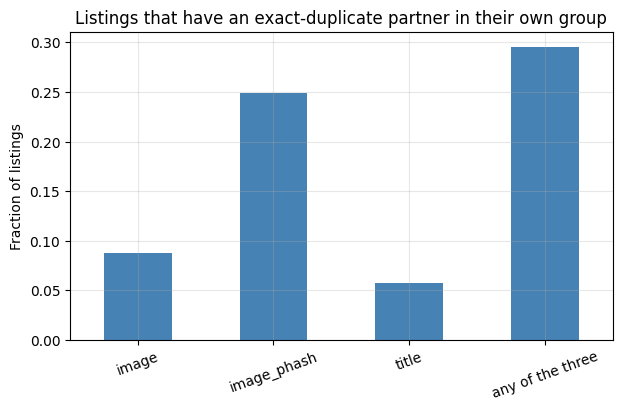

Listings NOT solved by any exact match: 0.704


In [ ]:
cols = ["image", "image_phash", "title"]
has_partner = {c: train_df.duplicated(["label_group", c], keep=False) for c in cols}
has_partner["any of the three"] = has_partner["image"] | has_partner["image_phash"] | has_partner["title"]

frac = pd.Series({k: v.mean() for k, v in has_partner.items()})
print(frac.round(3))

frac.plot(kind="bar", figsize=(7, 4), color="steelblue")
plt.ylabel("Fraction of listings")
plt.title("Listings that have an exact-duplicate partner in their own group")
plt.xticks(rotation=20)
plt.grid(alpha=0.3)
plt.show()
print("Listings NOT solved by any exact match:", round(1 - frac["any of the three"], 3))

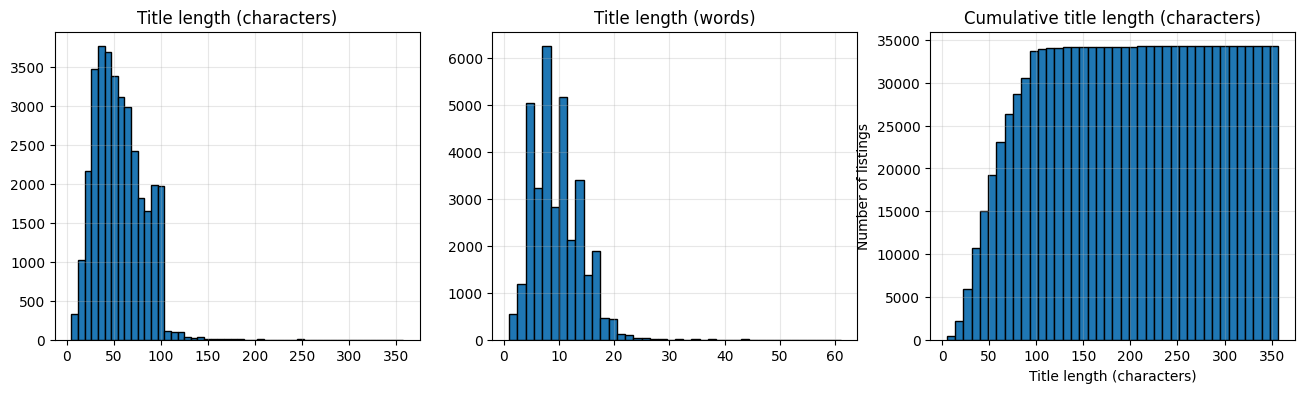

          title_len       n_words
count  34250.000000  34250.000000
mean      56.163474      9.414861
std       25.100492      4.446719
min        5.000000      1.000000
25%       36.000000      6.000000
50%       53.000000      9.000000
75%       73.000000     12.000000
max      357.000000     61.000000


In [ ]:
train_df["title_len"] = train_df.title.str.len()
train_df["n_words"] = train_df.title.str.split().str.len()

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(train_df.title_len, bins=50, edgecolor="black")
ax[0].set_title("Title length (characters)")

ax[1].hist(train_df.n_words, bins=40, edgecolor="black")
ax[1].set_title("Title length (words)")


ax[2].hist(train_df.title_len, bins=40, cumulative=True,edgecolor="black")
ax[2].set_title("Cumulative title length (characters)")
ax[2].set_xlabel("Title length (characters)")
ax[2].set_ylabel("Number of listings")
for a in ax: a.grid(alpha=0.3)
plt.show()
print(train_df[["title_len", "n_words"]].describe())

In [ ]:
def same_col1_diff_col2(df, col1, col2,max_examples=10):
  duplicated_diff = df[df.groupby(col1)[col2].transform('nunique') > 1].sort_values(col1)
  if len(duplicated_diff)==0:
    print("No such item found")
    return
  n=min(len(duplicated_diff),max_examples)
  duplicated_diff=duplicated_diff.head(n)
  print(duplicated_diff[[col1,col2,]])
print("-"*20)
print("same label_group but diff image_phash")
same_col1_diff_col2(train_df,"label_group","image_phash")
print("-"*20)
print("same label_group but diff title")
same_col1_diff_col2(train_df,"label_group","title")
print("-"*20)
print("same title but diff label_group")
same_col1_diff_col2(train_df,"title","label_group")
print("-"*20)
print("same image but diff label_group")
same_col1_diff_col2(train_df,"image","label_group")

--------------------
same label_group but diff image_phash
       label_group       image_phash
3874        258047  e925873ed09cd08f
31859       258047  ea97861c926a71e3
6738        258047  e9b5833e929e909c
12367       297977  838436c07dff19e4
7613        297977  bfc3cc1cc636c14c
31001       645628  8e68d943d6d8f48c
11716       645628  fbcf38c790d086b0
27972       645628  c89817483f3f398e
20122       645628  eb3d318d4bc61a25
32085       645628  d5d4231fd2688d17
--------------------
same label_group but diff title
       label_group                                              title
3874        258047  Sarung celana wadimor original 100% dewasa dan...
6738        258047    SARUNG CELANA WADIMOR DEWASA HITAM POLOS SARCEL
31859       258047  WARNA RANDOM ACAK Sarung Celana Wadimor MURAH ...
12367       297977  RELIZA WALL STICKER PENGUKUR TINGGI BADAN JERA...
7613        297977  Wall Sticker / WallSticker -  Submarine Measur...
27972       645628                            LVN COLLAGEN / 

In [ ]:
# titles with lots of symbols
sym_ratio = train_df.title.apply(lambda x: sum((not c.isalnum()) and (not c.isspace()) for c in x) / max(len(x), 1))
print("Titles with many symbols:",len(train_df[sym_ratio > 0.2]))
display(train_df[sym_ratio > 0.2][["title", "label_group"]].head(8))


Titles with many symbols: 11


,title,label_group
4440,DOT / Nipple / Teat AVENT Natural 2.0 2pcs/pac...,689574692
6657,Promo !!!!!!!!! Pixy Tint Me / Liptint Pixy,1649239857
8005,Ottogi Cheese Ramen \xeb\xb3\xb4\xeb\x93\xa4\x...,4113254005
10705,"b""Tanakan Tablet (30's)""",542043403
26626,Anti crack soft anti banting iPhone 5/5G/5S/5S...,3717044186
26678,Mukena Bali Polos Rayon Janger Jumbo rample Ad...,905946020
28658,Kemiri bulat......,2757892305
29585,12 Size Sakura Pigma Micron Pen-SIZE :1.0/005/...,2680726682


# Challenges and Questions

## `Challenges:`
Items with the following characteristics pose as challenges:
- Same titles but different labels
- Same image but different labels
- Same label but title and image different
- same label but different image_phash
- Almost same image but different image_phash
- noisy titles with symbols and units and numbers
- almost similar images but with camera angle or lighting changed
- Mixed languages of Indo-English origin
- Same images but one with text in it and one without it

## `Questions:`
### What makes two listings belong to the same product?
- In general, having similar titles ,images and image_phash makes the products similar. But this is not true in every case as shown by the outputs.

### Can product titles alone reliably determine whether two listings match?
- No, as showcased, there are cases where the titles are same but the labels are different.
- So, product titles alone cannot determine listings matching.

### Can images alone reliably determine whether two listings match?
- There are cases where the same image is usd for different labels.
- So, no it cannot be usd reliably alone in matching listings.
### What types of examples are likely to be difficult for a machine learning model?
The ML model can face most problems in the following cases:
- Same image but different labels
- same title but different labels

### What information in the dataset could potentially be useful for solving the problem?
- Most titles from the same label have common words.
- Most images from the same label have similar content.
- image_pash gives a cheap but often reliable signal of whether two images are similar.
- Exact duplicates are an easy match.
- Exact duplicates are mostly clean. Only 46 of 1,246 shared image files, 147 of 3,229 shared phashes and 73 of 962 shared titles cross groups.
[Note: Exact matches only cover a small part. They solve just 29.6% of listings, so 70.4% have no exact duplicate in their group.]
